In [9]:
# pandas: manipulación y análisis de datos en formato de tablas (dataframes)
import pandas as pd
# numpy: operaciones matemáticas y manejo de arreglos numéricos
import numpy as np
# matplotlib: creación de gráficas y visualizaciones base
import matplotlib.pyplot as plt
# seaborn: visualizaciones estadísticas con mejor estética que matplotlib
import seaborn as sns
# Carga del dataset
df = pd.read_excel('../Insumos/Caso Práctico Ecommerce.xlsx', sheet_name='Caso Práctico Ecommerce')

# Eliminamos las columnas de CVR (tasas de conversión) que vienen precalculadas
# en el dataset. La razón es que estas tasas se calcularon fila por fila, lo que
# significa que una fila con 1 vista y 1 compra pesa igual que una con 500,000
# vistas y 1,000 compras al momento de agregar. Nosotros recalcularemos los CVRs
# correctamente: sumando totales primero y dividiendo después.

del df['CVR (Item to Purchase)']
del df['CVR (Item to Checkout)']
del df['CVR (Checkout to Purchase)']

# Verificación rápida
print("Filas y columnas:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Filas y columnas: (274159, 8)

Columnas: ['Item name', 'Item ID', 'Device category', 'Date', 'Sessions', 'Viewed', 'Checked Out', 'Purchased']

Primeras filas:


,Item name,Item ID,Device category,Date,Sessions,Viewed,Checked Out,Purchased
0,Producto 2,683,mobile,13 sept 2025,122879,232240,6846,100
1,Producto 3,691,mobile,2026-03-04 00:00:00,154955,218088,2589,72
2,Producto 2,683,mobile,9 sept 2025,108203,214307,10117,206
3,(other),(other),(other),2026-03-04 00:00:00,399290,188758,0,0
4,Producto 2,683,mobile,2025-08-14 00:00:00,162920,188260,975,42


In [10]:
# ── LIMPIEZA ──────────────────────────────────────────────────────────────────

# Eliminamos espacios en los nombres de columnas por si hubiera alguno oculto
df.columns = df.columns.str.strip()

# Estandarización de la columna Date (Fecha)
# La columna tiene dos formatos mezclados: fechas en español ('13 sept 2025')
# y fechas en formato estándar ('2026-03-04 00:00:00'). Primero traducimos
# los nombres de mes al inglés para que pandas pueda interpretarlos correctamente
meses = {
    'ene': 'Jan', 'feb': 'Feb', 'mar': 'Mar', 'abr': 'Apr',
    'may': 'May', 'jun': 'Jun', 'jul': 'Jul', 'ago': 'Aug',
    'sep': 'Sep', 'oct': 'Oct', 'nov': 'Nov', 'dic': 'Dec'
}

for es, en in meses.items():
    df['Date'] = df['Date'].astype(str).str.replace(es, en, case=False)

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Eliminamos registros que no identifican un producto real
# (other) y (not set): valores que se general al no poder
# identificar el producto. Accesorios se excluye por una anomalía
# tiene más Checkouts (inicios de compra) que Vistas, lo que indica que el
# producto se agrega al carrito por otras vías sin generar evento de vista
productos_excluir = ['(other)', '(not set)', 'Accesorios']
df = df[~df['Item name'].isin(productos_excluir)].copy()


# Eliminamos dispositivos con volumen irrelevante para el análisis
# smart tv representa menos del 0.01% de las sesiones — cualquier CVR
# calculado sobre ese volumen no es estadísticamente confiable.
# (other) no permite identificar el dispositivo, por lo tanto no es accionable.
dispositivos_excluir = ['(other)', 'smart tv']
df = df[~df['Device category'].isin(dispositivos_excluir)].copy()

print("Dispositivos después del filtro:", df['Device category'].unique())


Dispositivos después del filtro: ['mobile' 'tablet' 'desktop']


C:\Users\mnztr\AppData\Local\Temp\ipykernel_15908\1448105235.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [11]:
# Calculamos el porcentaje de cada dispositivo sobre el total de sesiones
dist_dispositivos = df.groupby('Device category')['Sessions'].sum().sort_values(ascending=False)
dist_dispositivos = pd.DataFrame({
    'Sesiones': dist_dispositivos,
    '% del total': (dist_dispositivos / dist_dispositivos.sum() * 100).round(2)
})

display(dist_dispositivos.style
    .format({'Sesiones': '{:,.0f}', '% del total': '{:.2f}%'})
    .bar(subset=['% del total'], color='#5F9EA0')
    .set_caption('Distribución de sesiones por dispositivo')
)

,Sesiones,% del total
Device category,,
mobile,"16,110,206",93.33%
desktop,"690,346",4.00%
tablet,"460,243",2.67%


In [12]:
# ── FUNNEL GENERAL POR PRODUCTO ───────────────────────────────────────────────

# Sumamos los totales por producto primero y luego calculamos los CVRs
# (tasas de conversión). Este orden es importante: si calculáramos el CVR
# fila por fila y luego promediáramos, cada fila pesaría igual sin importar
# su volumen, distorsionando el resultado final.

funnel = df.groupby('Item name').agg(
    Vistas=('Viewed', 'sum'),
    Checkouts=('Checked Out', 'sum'),
    Compras=('Purchased', 'sum')
).reset_index()

# Calculamos los tres CVRs (tasas de conversión) sobre los totales
funnel['CVR Vista→Checkout']   = (funnel['Checkouts'] / funnel['Vistas'] * 100).round(2)
funnel['CVR Checkout→Compra']  = (funnel['Compras'] / funnel['Checkouts'] * 100).round(2)
funnel['CVR Total']            = (funnel['Compras'] / funnel['Vistas'] * 100).round(4)

funnel = funnel.sort_values('Vistas', ascending=False).reset_index(drop=True)

display(funnel.style
    .format({
        'Vistas': '{:,.0f}',
        'Checkouts': '{:,.0f}',
        'Compras': '{:,.0f}',
        'CVR Vista→Checkout': '{:.2f}%',
        'CVR Checkout→Compra': '{:.2f}%',
        'CVR Total': '{:.4f}%'
    })
    .bar(subset=['CVR Total'], color='#5F9EA0')
    .set_caption('Funnel general por producto — período completo Jul 2025 a Mar 2026')
)

,Item name,Vistas,Checkouts,Compras,CVR Vista→Checkout,CVR Checkout→Compra,CVR Total
0,Producto 2,"5,788,315","241,943","18,558",4.18%,7.67%,0.3206%
1,Producto 3,"5,263,310","199,350","9,813",3.79%,4.92%,0.1864%
2,Producto 4,"2,319,015","133,653","9,875",5.76%,7.39%,0.4258%
3,Producto 5,"744,885","13,360",592,1.79%,4.43%,0.0795%
4,Producto 1,"454,241","171,255","8,848",37.70%,5.17%,1.9479%
5,Kit de Producto 5 y accesorios,"303,068","9,056",431,2.99%,4.76%,0.1422%


In [13]:
# ── ANÁLISIS TEMPORAL ─────────────────────────────────────────────────────────

# Creamos una columna YearMonth (Año-Mes) para agrupar por período mensual
df['YearMonth'] = df['Date'].dt.to_period('M')

# Agrupamos por producto y mes sumando totales antes de calcular CVRs
temporal = df.groupby(['Item name', 'YearMonth']).agg(
    Vistas=('Viewed', 'sum'),
    Checkouts=('Checked Out', 'sum'),
    Compras=('Purchased', 'sum')
).reset_index()

temporal['CVR Total'] = (temporal['Compras'] / temporal['Vistas'] * 100).round(4)
temporal['YearMonth'] = temporal['YearMonth'].astype(str)

productos = temporal['Item name'].unique()

Item name,Kit de Producto 5 y accesorios,Producto 1,Producto 2,Producto 3,Producto 4,Producto 5
YearMonth,,,,,,
2025-07,0.4412%,0.5102%,0.0000%,0.2369%,0.6502%,0.1348%
2025-08,0.1075%,7.2580%,0.2028%,0.1787%,0.4949%,0.1849%
2025-09,0.5260%,7.2249%,0.1887%,0.3641%,0.1469%,0.1491%
2025-10,0.0360%,1.6193%,0.3588%,0.3794%,0.4237%,0.0000%
2025-11,0.0162%,2.2173%,0.8343%,0.4389%,0.7899%,0.0826%
2025-12,0.1387%,2.1721%,0.4649%,0.7401%,0.8289%,0.7360%
2026-01,0.0723%,1.5019%,0.3148%,0.4009%,0.3272%,0.8136%
2026-02,0.0000%,1.8588%,0.3291%,0.1363%,0.3603%,0.0568%
2026-03,0.0000%,3.5148%,0.5362%,0.0765%,0.5332%,0.0569%


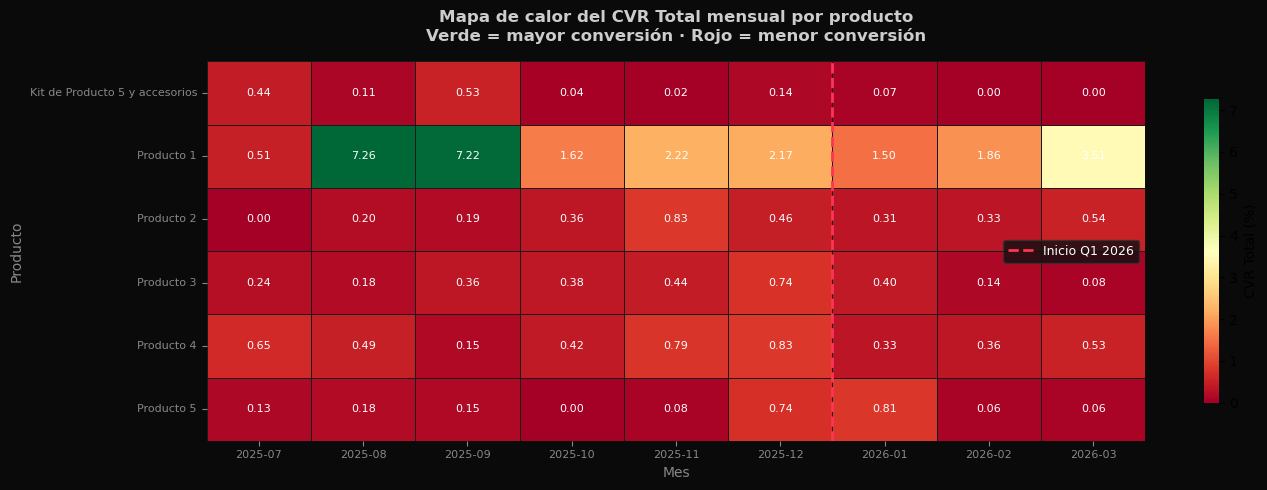

In [14]:
# ── TABLA MENSUAL DE CVR TOTAL POR PRODUCTO ───────────────────────────────────

# El equipo detectó una disminución en la tasa de conversión en los últimos meses.
# Antes de cualquier conclusión, necesitamos entender cómo se comportó el CVR
# (tasa de conversión) mes a mes por producto — si la caída es reciente y abrupta,
# gradual, o específica de algún producto. Esta tabla es el punto de partida
# para identificar patrones temporales en los datos.

# Pivoteamos (reorganizamos) la tabla mensual para tener productos en columnas
# y meses en filas, lo que facilita la lectura comparativa
tabla_mensual = temporal.pivot_table(
    index='YearMonth',
    columns='Item name',
    values='CVR Total'
).round(4)

# ── VERSIÓN TABLA CON FORMATO ─────────────────────────────────────────────────

# Resaltamos en rojo los valores que caen por debajo del promedio H2 2025
# de cada producto, para que el quiebre sea evidente sin necesidad de
# interpretar los números crudos

promedios_h2 = tabla_mensual[tabla_mensual.index <= '2025-12'].mean()

def resaltar_caida(col):
    promedio = promedios_h2[col.name]
    return [
        'background-color: #3d0000; color: #ff6b6b' if (pd.notna(v) and v < promedio)
        else 'background-color: #003d1a; color: #6bffaa' if pd.notna(v)
        else ''
        for v in col
    ]

display(tabla_mensual.style
    .apply(resaltar_caida)
    .format('{:.4f}%', na_rep='-')
    .set_caption(
        'CVR Total (tasa de conversión) mensual por producto. '
        'Rojo: por debajo del promedio H2 2025. Verde: por encima.'
    )
)

# ── VERSIÓN HEATMAP (MAPA DE CALOR) ───────────────────────────────────────────

# El heatmap complementa la tabla: donde la tabla da el número exacto,
# el heatmap hace visible el patrón espacial — qué tan generalizado es
# el quiebre y si ocurre al mismo tiempo en todos los productos o no.
# Un quiebre simultáneo en varios productos en el mismo mes apunta a una
# causa común (campaña, cambio técnico), mientras que quiebres escalonados
# apuntan a causas independientes por producto.

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0f0f0f')

sns.heatmap(
    tabla_mensual.T,
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='#1a1a1a',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8, 'color': 'white'},
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'CVR Total (%)'}
)

# Línea vertical que marca el inicio de Q1 2026
# Los meses están en el eje X, enero 2026 es el índice 6 (0-based)
ax.axvline(x=6, color='#ff3355', linewidth=2, linestyle='--', label='Inicio Q1 2026')
ax.legend(fontsize=9, labelcolor='white', facecolor='#0f0f0f', edgecolor='#333333')

ax.set_title(
    'Mapa de calor del CVR Total mensual por producto\n'
    'Verde = mayor conversión · Rojo = menor conversión',
    fontsize=12, fontweight='bold', color='#cccccc', pad=15
)
ax.set_xlabel('Mes', color='#888888')
ax.set_ylabel('Producto', color='#888888')
ax.tick_params(colors='#888888', labelsize=8)

for _, spine in ax.spines.items():
    spine.set_edgecolor('#222222')

plt.tight_layout()
plt.show()

## Conclusión del análisis mensual

La tabla y el mapa de calor revelan un patrón que no es visible si se analiza
el período completo como un bloque único.

El CVR Total (tasa de conversión) se comporta de forma relativamente estable
entre julio y diciembre 2025, con variaciones normales mes a mes. Sin embargo,
a partir de febrero 2026 se observa una caída simultánea y pronunciada en
**Producto 3, Producto 5 y Kit de Producto 5 y accesorios**, mientras que
**Producto 4** muestra un deterioro más gradual que viene desde septiembre 2025.

Que el quiebre ocurra en el mismo mes en varios productos al mismo tiempo
no es casualidad — apunta a una causa común, posiblemente un cambio en la
estrategia de adquisición de tráfico. Que Producto 4 tenga un patrón distinto
sugiere que su problema tiene una naturaleza diferente.

Con base en esto, el análisis se divide en dos períodos:

- **H2 2025** (julio — diciembre 2025): período de referencia o línea base,
donde el comportamiento es estable y representa el desempeño histórico normal.
- **Q1 2026** (enero — marzo 2026): período reciente donde se concentra el
deterioro detectado por el equipo.

Esta partición no es arbitraria — está dictada por los datos.

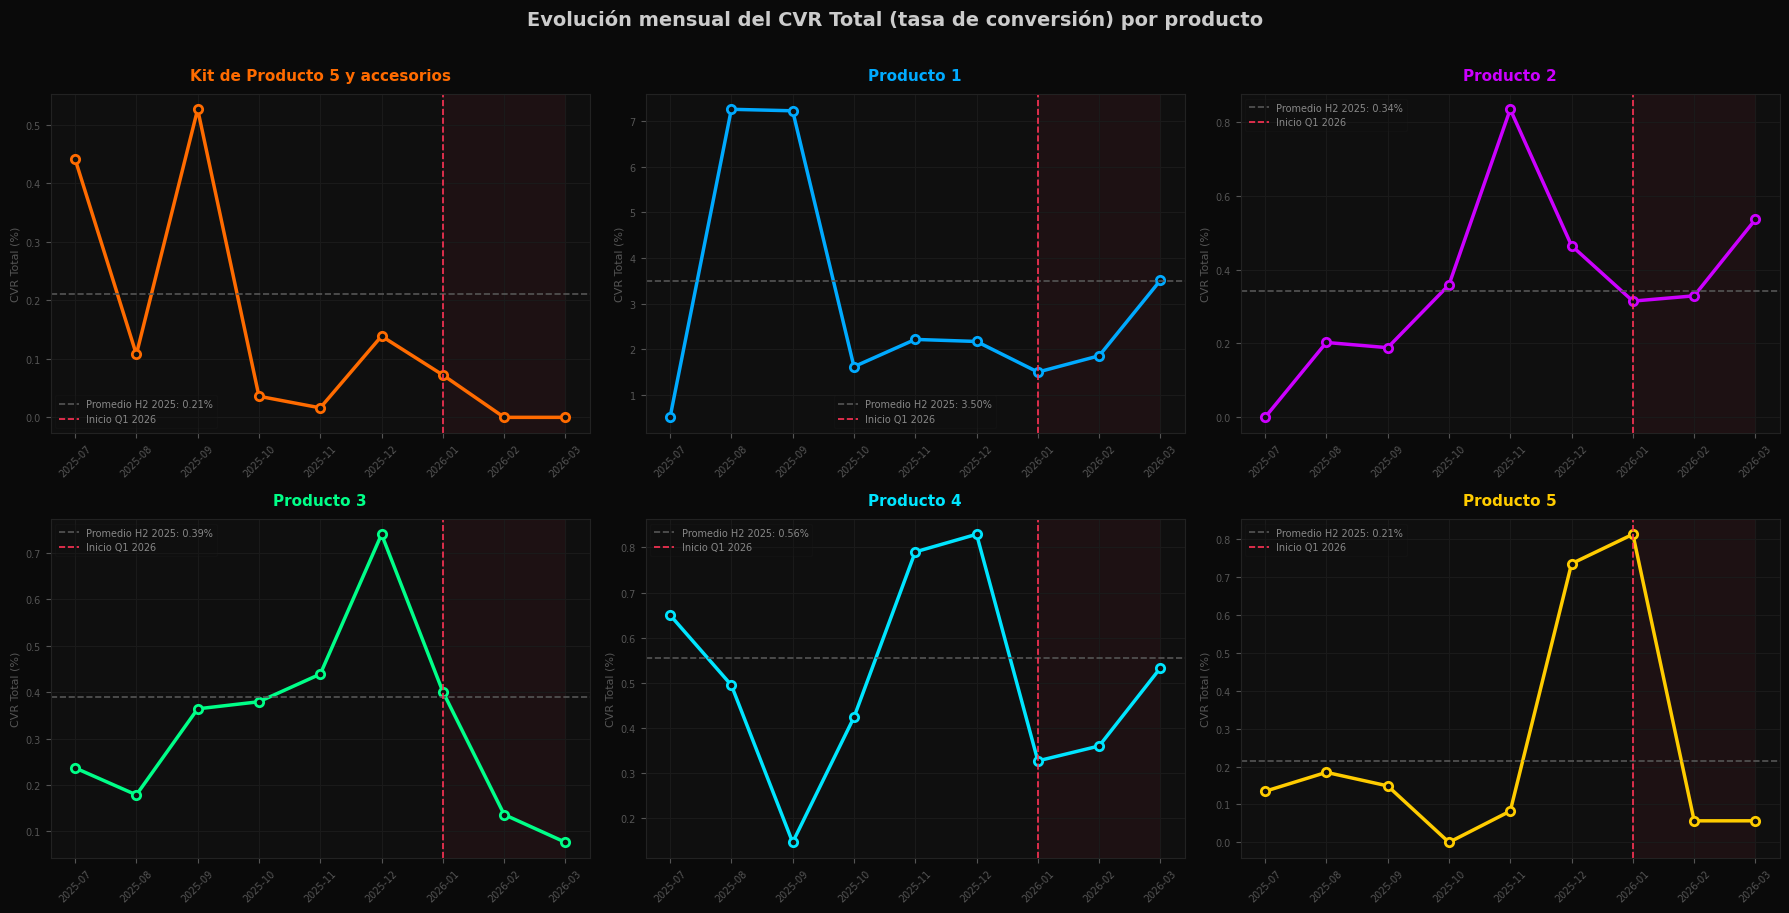

In [15]:
# ── EVOLUCIÓN MENSUAL DEL CVR TOTAL POR PRODUCTO (versión neon) ───────────────

colores_neon = ['#ff6b00', '#00aaff', '#cc00ff', '#00ff88', '#00e5ff', '#ffcc00']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor('#0a0a0a')
axes = axes.flatten()

for i, producto in enumerate(productos):
    ax = axes[i]
    ax.set_facecolor('#0f0f0f')
    datos = temporal[temporal['Item name'] == producto].copy()

    h2 = datos[datos['YearMonth'] <= '2025-12']['CVR Total'].mean()

    ax.plot(datos['YearMonth'], datos['CVR Total'],
            marker='o', color=colores_neon[i], linewidth=2.5,
            markersize=6, markerfacecolor='#0f0f0f',
            markeredgewidth=2, markeredgecolor=colores_neon[i])

    ax.axhline(y=h2, color='#555555', linestyle='--',
               linewidth=1.2, label=f'Promedio H2 2025: {h2:.2f}%')

    ax.axvline(x='2026-01', color='#ff3355', linestyle='--',
               linewidth=1.2, label='Inicio Q1 2026')

    meses = datos['YearMonth'].tolist()
    idx_q1 = meses.index('2026-01') if '2026-01' in meses else None
    if idx_q1:
        ax.axvspan(meses[idx_q1], meses[-1], alpha=0.06, color='#ff3355')

    ax.set_title(producto, fontsize=11, fontweight='bold',
                 color=colores_neon[i], pad=10)
    ax.set_ylabel('CVR Total (%)', fontsize=8, color='#555555')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7, colors='#555555')
    ax.tick_params(axis='y', labelsize=7, colors='#555555')
    ax.legend(fontsize=7, framealpha=0.2, labelcolor='#888888',
              facecolor='#0f0f0f', edgecolor='#222222')

    for spine in ax.spines.values():
        spine.set_edgecolor('#222222')

    ax.grid(True, color='#1a1a1a', linewidth=0.8)

plt.suptitle('Evolución mensual del CVR Total (tasa de conversión) por producto',
             fontsize=14, fontweight='bold', y=1.01, color='#cccccc')
plt.tight_layout()
plt.show()

## Análisis temporal del CVR Total por producto

La gráfica muestra la evolución mensual del CVR Total (tasa de conversión) entre julio 2025 y marzo 2026.
La línea punteada gris representa el promedio del H2 2025 (segundo semestre de 2025) como referencia histórica,
y la zona sombreada en rojo marca el inicio de Q1 2026 (primer trimestre de 2026).

Cuatro patrones emergen claramente:

- **Producto 3 y Producto 5** presentan un quiebre abrupto en febrero 2026: el CVR colapsa
por debajo de su línea base justo cuando el volumen de vistas se dispara. Esto sugiere
que ambos productos recibieron una entrada masiva de tráfico sin intención de compra,
probablemente originada por la misma fuente.

- **Producto 4** muestra un comportamiento distinto: la caída es más gradual y viene
desde septiembre 2025, lo que apunta a un problema estructural en el proceso de compra
más que a un evento puntual de tráfico.

- **Kit de Producto 5 y accesorios** también presenta un quiebre en febrero 2026 similar
al de Producto 3 y Producto 5, sin embargo su volumen de vistas es considerablemente menor
(82,000 vistas en Q1 2026 vs 3.5 millones de Producto 3), por lo que el impacto absoluto
de recuperar su CVR es limitado comparado con los tres seleccionados.

- **Producto 1 y Producto 2** se mantienen por encima o cerca de su línea base en Q1 2026,
por lo que no representan una oportunidad de mejora prioritaria en este momento.

Estos patrones guían la selección de los tres productos con mayor oportunidad de mejora:
**Producto 3, Producto 4 y Producto 5**.

In [16]:
# ── COMPARATIVA H2 2025 vs Q1 2026 ───────────────────────────────────────────

# Ahora que los datos justifican la partición, calculamos el CVR Total
# (tasa de conversión) para cada período sumando totales primero y dividiendo
# después. Esto nos da un número por producto por período que refleja
# el desempeño real sin distorsiones por volumen.

h2_2025 = df[df['Date'].between('2025-07-01', '2025-12-31')]
q1_2026 = df[df['Date'] >= '2026-01-01']

def calcular_cvr(data):
    g = data.groupby('Item name').agg(
        Vistas=('Viewed', 'sum'),
        Checkouts=('Checked Out', 'sum'),
        Compras=('Purchased', 'sum')
    ).reset_index()
    g['CVR Total'] = (g['Compras'] / g['Vistas'] * 100).round(4)
    return g.set_index('Item name')

f_h2 = calcular_cvr(h2_2025)
f_q1 = calcular_cvr(q1_2026)

# Construimos la tabla comparativa
comparativa = pd.DataFrame({
    'Vistas H2 2025':     f_h2['Vistas'],
    'CVR H2 2025 (%)':    f_h2['CVR Total'],
    'Vistas Q1 2026':     f_q1['Vistas'],
    'CVR Q1 2026 (%)':    f_q1['CVR Total'],
})

# El cambio porcentual nos dice cuánto se movió el CVR relativo a su propia
# línea base — es más informativo que el cambio absoluto porque pone en
# perspectiva la magnitud de la caída independientemente del nivel de partida
comparativa['Cambio (%)'] = (
    (comparativa['CVR Q1 2026 (%)'] - comparativa['CVR H2 2025 (%)'])
    / comparativa['CVR H2 2025 (%)'] * 100
).round(1)

comparativa = comparativa.sort_values('Cambio (%)')

# Coloreamos el cambio: rojo para caídas, verde para mejoras
def colorear_cambio(val):
    if val < 0:
        return 'background-color: #3d0000; color: #ff6b6b; font-weight: bold'
    else:
        return 'background-color: #003d1a; color: #6bffaa; font-weight: bold'

display(comparativa.style
    .applymap(colorear_cambio, subset=['Cambio (%)'])
    .format({
        'Vistas H2 2025':  '{:,.0f}',
        'CVR H2 2025 (%)': '{:.4f}%',
        'Vistas Q1 2026':  '{:,.0f}',
        'CVR Q1 2026 (%)': '{:.4f}%',
        'Cambio (%)':      '{:.1f}%'
    })
    .set_caption(
        'Comparativa de CVR Total (tasa de conversión) H2 2025 vs Q1 2026. '
        'Ordenado de mayor a menor caída.'
    )
)

C:\Users\mnztr\AppData\Local\Temp\ipykernel_15908\1237567793.py:49: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(colorear_cambio, subset=['Cambio (%)'])


,Vistas H2 2025,CVR H2 2025 (%),Vistas Q1 2026,CVR Q1 2026 (%),Cambio (%)
Item name,,,,,
Kit de Producto 5 y accesorios,"220,586",0.1909%,"82,482",0.0121%,-93.7%
Producto 5,"41,174",0.2040%,"703,711",0.0722%,-64.6%
Producto 3,"1,782,393",0.2971%,"3,480,917",0.1298%,-56.3%
Producto 4,"1,572,712",0.4542%,"746,303",0.3659%,-19.4%
Producto 1,"283,945",1.8856%,"170,296",2.0517%,8.8%
Producto 2,"4,595,974",0.3108%,"1,192,341",0.3585%,15.3%


## Comparativa H2 2025 vs Q1 2026

La tabla anterior cuantifica lo que la gráfica de evolución mensual mostraba
visualmente: qué productos están cayendo, cuánto cayeron y con qué volumen.

El cambio porcentual es la métrica clave de selección porque pone en perspectiva
la magnitud de la caída relativa al propio desempeño histórico de cada producto —
un producto que cae de 0.5% a 0.1% tiene el mismo cambio absoluto que uno que
cae de 1.0% a 0.6%, pero el primero perdió el 80% de su conversión mientras
que el segundo perdió el 40%.

Sin embargo el cambio porcentual solo no es suficiente para priorizar. El
**Kit de Producto 5 y accesorios** muestra la mayor caída (−94%) pero con
apenas 82,000 vistas en Q1 2026, su impacto absoluto en compras es limitado.
El criterio de selección final combina tres factores:

- **Magnitud de la caída**: qué tan deteriorado está el CVR respecto a su línea base
- **Volumen de vistas**: cuántos usuarios están siendo afectados
- **Claridad del diagnóstico**: si los datos permiten identificar una causa accionable

Con base en estos tres criterios, los productos con mayor oportunidad de mejora son
**Producto 3, Producto 4 y Producto 5**, que son el foco del análisis que sigue.

,Device category,Vistas,Checkouts,Compras,CVR Vista→Checkout (%),CVR Checkout→Compra (%),CVR Total (%),Período
0,desktop,"79,359","10,127","1,060",12.76%,10.47%,1.3357%,H2 2025
1,mobile,"1,662,031","84,771","4,223",5.10%,4.98%,0.2541%,H2 2025
2,tablet,"41,003","1,231",13,3.00%,1.06%,0.0317%,H2 2025
3,desktop,"58,124","4,716",674,8.11%,14.29%,1.1596%,Q1 2026
4,mobile,"3,215,639","96,570","3,819",3.00%,3.95%,0.1188%,Q1 2026
5,tablet,"207,154","1,935",24,0.93%,1.24%,0.0116%,Q1 2026


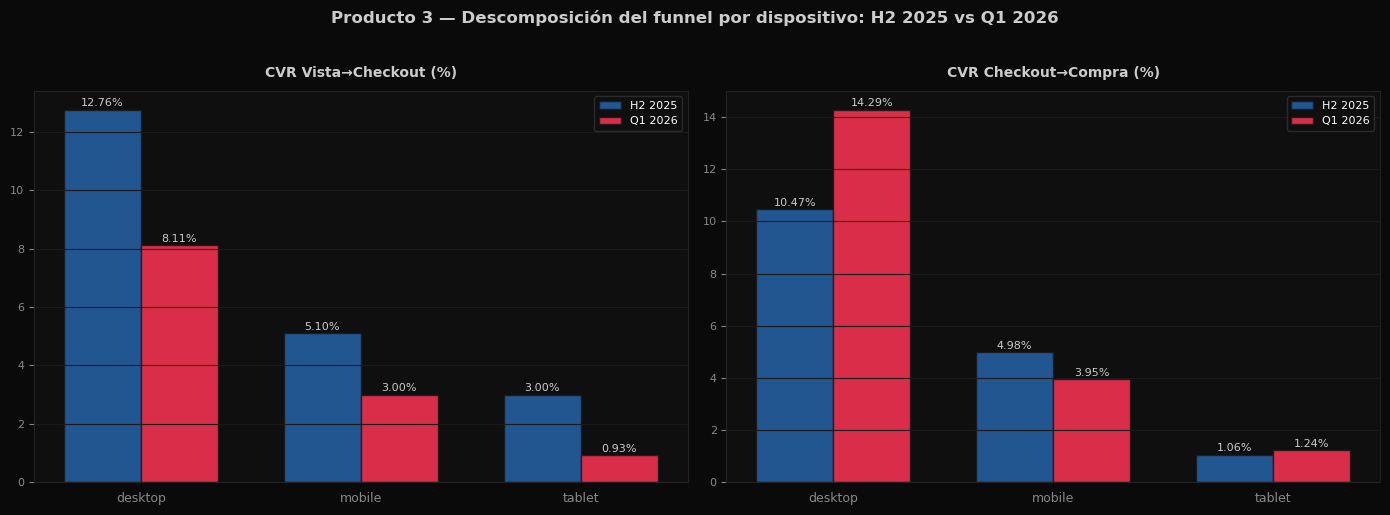

In [17]:
# ── DIAGNÓSTICO PRODUCTO 3 ────────────────────────────────────────────────────

# Para diagnosticar correctamente necesitamos descomponer el CVR Total
# (tasa de conversión) en sus dos etapas:
# - CVR Vista→Checkout: mide si la página del producto convence al usuario
#   de iniciar la compra
# - CVR Checkout→Compra: mide si el proceso de pago es lo suficientemente
#   fluido para que el usuario complete la transacción
#
# Si la caída está en la primera etapa, el problema es de intención —
# el usuario no está convencido. Si está en la segunda, es de fricción —
# el usuario quiere comprar pero algo lo detiene.

p3_h2 = h2_2025[h2_2025['Item name'] == 'Producto 3']
p3_q1 = q1_2026[q1_2026['Item name'] == 'Producto 3']

def diagnostico_funnel(data, label):
    g = data.groupby('Device category').agg(
        Vistas=('Viewed', 'sum'),
        Checkouts=('Checked Out', 'sum'),
        Compras=('Purchased', 'sum')
    ).reset_index()
    g['CVR Vista→Checkout (%)']  = (g['Checkouts'] / g['Vistas'] * 100).round(2)
    g['CVR Checkout→Compra (%)'] = (g['Compras'] / g['Checkouts'] * 100).round(2)
    g['CVR Total (%)']           = (g['Compras'] / g['Vistas'] * 100).round(4)
    g['Período'] = label
    return g.set_index('Device category')

diag_h2 = diagnostico_funnel(p3_h2, 'H2 2025')
diag_q1 = diagnostico_funnel(p3_q1, 'Q1 2026')

# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────

comparativa_p3 = pd.concat([diag_h2, diag_q1]).reset_index()

display(comparativa_p3.style
    .format({
        'Vistas':                   '{:,.0f}',
        'Checkouts':                '{:,.0f}',
        'Compras':                  '{:,.0f}',
        'CVR Vista→Checkout (%)':  '{:.2f}%',
        'CVR Checkout→Compra (%)': '{:.2f}%',
        'CVR Total (%)':           '{:.4f}%'
    })
    .set_caption('Producto 3 — Descomposición del funnel por dispositivo: H2 2025 vs Q1 2026')
)

# ── GRÁFICA ───────────────────────────────────────────────────────────────────

# Graficamos las dos etapas del funnel lado a lado para cada dispositivo,
# comparando H2 2025 vs Q1 2026. Esto hace visible de un vistazo en qué
# etapa ocurre la mayor caída y si el problema es homogéneo entre dispositivos
# o está concentrado en alguno específico.

dispositivos = ['desktop', 'mobile', 'tablet']
metricas = ['CVR Vista→Checkout (%)', 'CVR Checkout→Compra (%)']
colores_periodo = {'H2 2025': '#2563a8', 'Q1 2026': '#ff3355'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0a0a')

for j, metrica in enumerate(metricas):
    ax = axes[j]
    ax.set_facecolor('#0f0f0f')

    x = np.arange(len(dispositivos))
    ancho = 0.35

    for k, (periodo, data) in enumerate([('H2 2025', diag_h2), ('Q1 2026', diag_q1)]):
        valores = [data.loc[d, metrica] if d in data.index else 0 for d in dispositivos]
        bars = ax.bar(x + k * ancho, valores, ancho,
                      label=periodo, color=colores_periodo[periodo],
                      alpha=0.85, edgecolor='#1a1a1a')

        # Etiquetas de valor encima de cada barra
        for bar, val in zip(bars, valores):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f'{val:.2f}%', ha='center', va='bottom',
                    fontsize=8, color='#cccccc')

    ax.set_title(metrica, fontsize=10, fontweight='bold', color='#cccccc', pad=10)
    ax.set_xticks(x + ancho / 2)
    ax.set_xticklabels(dispositivos, color='#888888', fontsize=9)
    ax.tick_params(axis='y', colors='#888888', labelsize=8)
    ax.legend(fontsize=8, labelcolor='white',
              facecolor='#0f0f0f', edgecolor='#333333')
    ax.grid(axis='y', color='#1a1a1a', linewidth=0.8)

    for spine in ax.spines.values():
        spine.set_edgecolor('#222222')

plt.suptitle('Producto 3 — Descomposición del funnel por dispositivo: H2 2025 vs Q1 2026',
             fontsize=12, fontweight='bold', color='#cccccc', y=1.02)
plt.tight_layout()
plt.show()

## Diagnóstico — Producto 3

### ¿Dónde se rompe el funnel?

La descomposición del funnel (embudo de compra) por etapa y dispositivo revela
que la caída del CVR Total (tasa de conversión) en Producto 3 está concentrada
en la primera etapa: **CVR Vista→Checkout** (tasa de conversión de vista a
inicio de compra).

En mobile, que concentra el 92% del volumen, el CVR Vista→Checkout cayó de
5.1% en H2 2025 a 3.0% en Q1 2026 — una caída del 41%. El CVR Checkout→Compra
(tasa de conversión de inicio de compra a compra final) se mantuvo relativamente
estable en ambos períodos, lo que descarta que el problema esté en el proceso de pago.

### ¿Qué tipo de problema es?

Es un problema de **intención** (top funnel — parte superior del embudo).
Los usuarios llegan a la página del producto pero no se convencen de iniciar
la compra. Dado que el quiebre ocurre exactamente en febrero 2026 — el mismo
mes en que el volumen de vistas se multiplicó por 6 — la hipótesis más probable
es que una nueva fuente de tráfico comenzó a enviar usuarios que no son el
comprador ideal de este producto.

### Insight

El producto no cambió, el proceso de pago no cambió — lo que cambió fue
quién llegó a verlo. El tráfico nuevo de febrero 2026 no tiene intención
de compra, probablemente porque el mensaje de la campaña que lo originó
no está filtrando al comprador correcto.

,Device category,Vistas,Checkouts,Compras,CVR Vista→Checkout (%),CVR Checkout→Compra (%),CVR Total (%),Período
0,desktop,"50,189","7,124","1,004",14.19%,14.09%,2.0004%,H2 2025
1,mobile,"1,480,964","79,822","6,106",5.39%,7.65%,0.4123%,H2 2025
2,tablet,"41,559",498,34,1.20%,6.83%,0.0818%,H2 2025
3,desktop,"24,003","2,735",355,11.39%,12.98%,1.4790%,Q1 2026
4,mobile,"699,007","42,940","2,359",6.14%,5.49%,0.3375%,Q1 2026
5,tablet,"23,293",534,17,2.29%,3.18%,0.0730%,Q1 2026


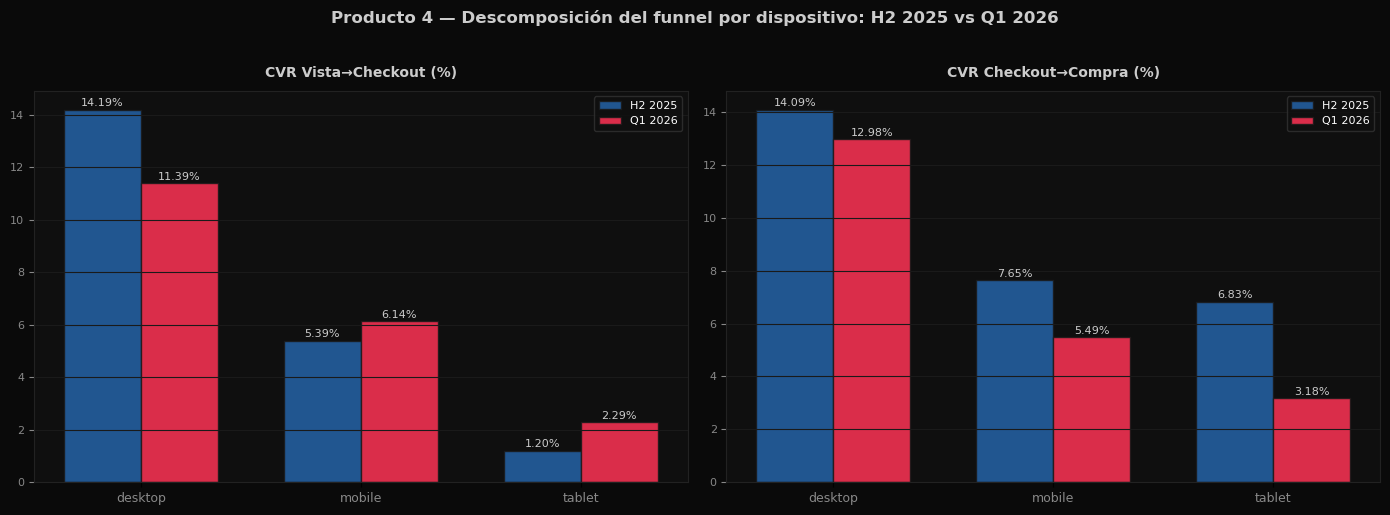

In [18]:
# ── DIAGNÓSTICO PRODUCTO 4 ────────────────────────────────────────────────────

# Mismo análisis que Producto 3: descomponemos el CVR Total en sus dos etapas
# y lo desglosamos por dispositivo para identificar exactamente dónde se rompe
# el funnel y si el problema es de intención (top funnel) o fricción (bottom funnel)

p4_h2 = h2_2025[h2_2025['Item name'] == 'Producto 4']
p4_q1 = q1_2026[q1_2026['Item name'] == 'Producto 4']

diag_h2_p4 = diagnostico_funnel(p4_h2, 'H2 2025')
diag_q1_p4 = diagnostico_funnel(p4_q1, 'Q1 2026')

# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────

comparativa_p4 = pd.concat([diag_h2_p4, diag_q1_p4]).reset_index()

display(comparativa_p4.style
    .format({
        'Vistas':                   '{:,.0f}',
        'Checkouts':                '{:,.0f}',
        'Compras':                  '{:,.0f}',
        'CVR Vista→Checkout (%)':  '{:.2f}%',
        'CVR Checkout→Compra (%)': '{:.2f}%',
        'CVR Total (%)':           '{:.4f}%'
    })
    .set_caption('Producto 4 — Descomposición del funnel por dispositivo: H2 2025 vs Q1 2026')
)

# ── GRÁFICA ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0a0a0a')

for j, metrica in enumerate(metricas):
    ax = axes[j]
    ax.set_facecolor('#0f0f0f')

    x = np.arange(len(dispositivos))
    ancho = 0.35

    for k, (periodo, data) in enumerate([('H2 2025', diag_h2_p4), ('Q1 2026', diag_q1_p4)]):
        valores = [data.loc[d, metrica] if d in data.index else 0 for d in dispositivos]
        bars = ax.bar(x + k * ancho, valores, ancho,
                      label=periodo, color=colores_periodo[periodo],
                      alpha=0.85, edgecolor='#1a1a1a')

        for bar, val in zip(bars, valores):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f'{val:.2f}%', ha='center', va='bottom',
                    fontsize=8, color='#cccccc')

    ax.set_title(metrica, fontsize=10, fontweight='bold', color='#cccccc', pad=10)
    ax.set_xticks(x + ancho / 2)
    ax.set_xticklabels(dispositivos, color='#888888', fontsize=9)
    ax.tick_params(axis='y', colors='#888888', labelsize=8)
    ax.legend(fontsize=8, labelcolor='white',
              facecolor='#0f0f0f', edgecolor='#333333')
    ax.grid(axis='y', color='#1a1a1a', linewidth=0.8)

    for spine in ax.spines.values():
        spine.set_edgecolor('#222222')

plt.suptitle('Producto 4 — Descomposición del funnel por dispositivo: H2 2025 vs Q1 2026',
             fontsize=12, fontweight='bold', color='#cccccc', y=1.02)
plt.tight_layout()
plt.show()

## Diagnóstico — Producto 4

### ¿Dónde se rompe el funnel?

El patrón de Producto 4 es el opuesto al de Producto 3. La descomposición
por etapa muestra que el **CVR Vista→Checkout** (tasa de conversión de vista
a inicio de compra) en mobile mejoró ligeramente entre H2 2025 y Q1 2026,
lo que indica que la página del producto está funcionando bien y los usuarios
tienen intención de comprar. Sin embargo, el **CVR Checkout→Compra** (tasa
de conversión de inicio de compra a compra final) en mobile cayó 28% en el
mismo período.

### ¿Qué tipo de problema es?

Es un problema de **fricción** (bottom funnel — parte inferior del embudo).
El usuario llega al producto, se convence de comprarlo e inicia el proceso
de pago, pero algo dentro de ese flujo lo detiene antes de completar
la transacción. A diferencia de Producto 3, aquí el problema no es quién
llega sino qué encuentra cuando intenta pagar.

La caída es gradual desde septiembre 2025 — no hay un quiebre abrupto en
febrero como en Producto 3 — lo que sugiere un deterioro estructural en
el proceso de pago más que un evento puntual de tráfico.

### Insight

El usuario ya tomó la decisión de comprar. La pérdida ocurre en el último
paso, que es el más costoso porque es el más cercano al ingreso. Un problema
en esta etapa tiene mayor urgencia relativa que un problema de intención,
porque el costo de adquisición del usuario ya fue pagado y la venta
se está perdiendo en el último metro.

,Device category,Vistas,Checkouts,Compras,CVR Vista→Checkout (%),CVR Checkout→Compra (%),CVR Total (%),Período
0,desktop,"7,303",367,28,5.03%,7.63%,0.3834%,H2 2025
1,mobile,"33,572","1,787",56,5.32%,3.13%,0.1668%,H2 2025
2,tablet,299,14,0,4.68%,0.00%,0.0000%,H2 2025
3,desktop,"12,047","1,416",141,11.75%,9.96%,1.1704%,Q1 2026
4,mobile,"657,780","9,567",364,1.45%,3.80%,0.0553%,Q1 2026
5,tablet,"33,884",209,3,0.62%,1.44%,0.0089%,Q1 2026


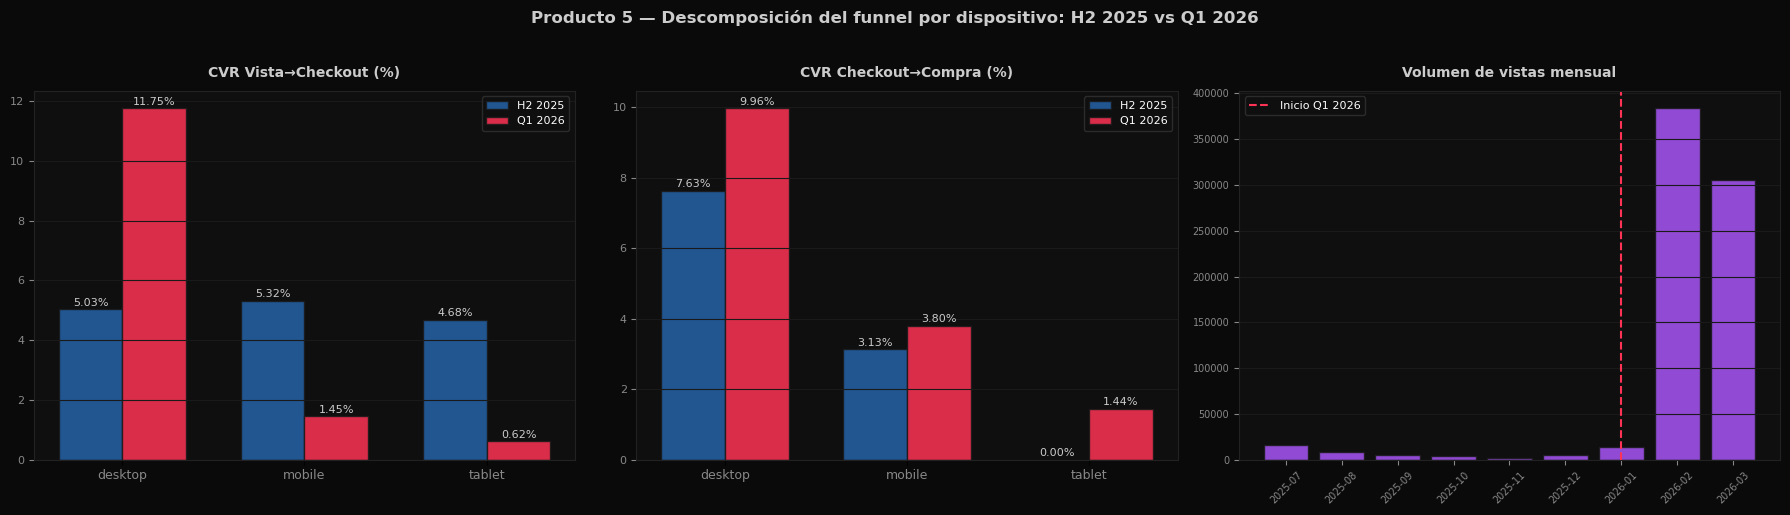

In [19]:
# ── DIAGNÓSTICO PRODUCTO 5 ────────────────────────────────────────────────────

# Producto 5 tiene la señal más llamativa del dataset: el volumen de vistas
# pasó de 14,000 en enero 2026 a 383,000 en febrero — un incremento de 27 veces
# en un solo mes. Descomponemos el funnel para entender si el problema está
# en la intención o en la fricción, y si es homogéneo entre dispositivos.

p5_h2 = h2_2025[h2_2025['Item name'] == 'Producto 5']
p5_q1 = q1_2026[q1_2026['Item name'] == 'Producto 5']

diag_h2_p5 = diagnostico_funnel(p5_h2, 'H2 2025')
diag_q1_p5 = diagnostico_funnel(p5_q1, 'Q1 2026')

# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────

comparativa_p5 = pd.concat([diag_h2_p5, diag_q1_p5]).reset_index()

display(comparativa_p5.style
    .format({
        'Vistas':                   '{:,.0f}',
        'Checkouts':                '{:,.0f}',
        'Compras':                  '{:,.0f}',
        'CVR Vista→Checkout (%)':  '{:.2f}%',
        'CVR Checkout→Compra (%)': '{:.2f}%',
        'CVR Total (%)':           '{:.4f}%'
    })
    .set_caption('Producto 5 — Descomposición del funnel por dispositivo: H2 2025 vs Q1 2026')
)

# ── GRÁFICA ───────────────────────────────────────────────────────────────────

# En Producto 5 agregamos una tercera gráfica de volumen de vistas por mes
# para hacer visible el spike (pico) de tráfico de febrero 2026 que es
# central para el diagnóstico. Sin este contexto de volumen, la caída
# del CVR podría interpretarse como un problema de página cuando en realidad
# es un problema de calidad de tráfico.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0a0a0a')

# Primeras dos gráficas: descomposición del funnel por etapa y dispositivo
for j, metrica in enumerate(metricas):
    ax = axes[j]
    ax.set_facecolor('#0f0f0f')

    x = np.arange(len(dispositivos))
    ancho = 0.35

    for k, (periodo, data) in enumerate([('H2 2025', diag_h2_p5), ('Q1 2026', diag_q1_p5)]):
        valores = [data.loc[d, metrica] if d in data.index else 0 for d in dispositivos]
        bars = ax.bar(x + k * ancho, valores, ancho,
                      label=periodo, color=colores_periodo[periodo],
                      alpha=0.85, edgecolor='#1a1a1a')

        for bar, val in zip(bars, valores):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f'{val:.2f}%', ha='center', va='bottom',
                    fontsize=8, color='#cccccc')

    ax.set_title(metrica, fontsize=10, fontweight='bold', color='#cccccc', pad=10)
    ax.set_xticks(x + ancho / 2)
    ax.set_xticklabels(dispositivos, color='#888888', fontsize=9)
    ax.tick_params(axis='y', colors='#888888', labelsize=8)
    ax.legend(fontsize=8, labelcolor='white',
              facecolor='#0f0f0f', edgecolor='#333333')
    ax.grid(axis='y', color='#1a1a1a', linewidth=0.8)

    for spine in ax.spines.values():
        spine.set_edgecolor('#222222')

# Tercera gráfica: volumen de vistas mensual — esta es la gráfica clave
# porque muestra el spike (pico) de febrero 2026 que explica la caída del CVR
ax = axes[2]
ax.set_facecolor('#0f0f0f')

p5_mensual = temporal[temporal['Item name'] == 'Producto 5']
ax.bar(p5_mensual['YearMonth'], p5_mensual['Vistas'],
       color='#a855f7', alpha=0.85, edgecolor='#1a1a1a')

ax.axvline(x='2026-01', color='#ff3355', linestyle='--',
           linewidth=1.5, label='Inicio Q1 2026')

ax.set_title('Volumen de vistas mensual', fontsize=10,
             fontweight='bold', color='#cccccc', pad=10)
ax.tick_params(axis='x', rotation=45, labelsize=7, colors='#888888')
ax.tick_params(axis='y', labelsize=7, colors='#888888')
ax.legend(fontsize=8, labelcolor='white',
          facecolor='#0f0f0f', edgecolor='#333333')
ax.grid(axis='y', color='#1a1a1a', linewidth=0.8)

for spine in ax.spines.values():
    spine.set_edgecolor('#222222')

plt.suptitle('Producto 5 — Descomposición del funnel por dispositivo: H2 2025 vs Q1 2026',
             fontsize=12, fontweight='bold', color='#cccccc', y=1.02)
plt.tight_layout()
plt.show()

## Diagnóstico — Producto 5

### ¿Dónde se rompe el funnel?

La descomposición del funnel por etapa y dispositivo, junto con la evolución del
volumen de vistas, revela un patrón similar al de Producto 3 pero con una señal
aún más extrema.

El **CVR Vista→Checkout** en mobile colapsó de 5.32% en H2 2025 a 1.45% en Q1 2026
— una caída del 73%. El **CVR Checkout→Compra** se mantuvo relativamente estable
(3.13% vs 3.80%), lo que descarta que el problema esté en el proceso de pago.

La tercera gráfica hace visible la causa: el volumen de vistas pasó de
~14,000 en enero 2026 a 383,000 en febrero — un incremento de **27 veces en un
solo mes** — y se mantuvo en 305,000 en marzo. Este spike (pico) masivo de tráfico
coincide exactamente con el quiebre del CVR.

### ¿Qué tipo de problema es?

Es un problema de **intención** (top funnel — parte superior del embudo),
idéntico en naturaleza al de Producto 3. El volumen de vistas se multiplicó
de forma repentina mientras las compras no crecieron en la misma proporción,
lo que indica que el tráfico nuevo no tiene intención de compra real.

Que el quiebre ocurra en el mismo mes que en Producto 3 (febrero 2026) y que ambos
compartan el mismo patrón — spike de vistas + colapso del CVR Vista→Checkout +
estabilidad del CVR Checkout→Compra — apunta a una **causa común**: una misma
fuente de tráfico que comenzó a enviar usuarios sin perfil comprador a ambos
productos simultáneamente.

### Insight

A diferencia de Producto 4, donde el usuario ya decidió comprar y la pérdida
ocurre en el pago, en Producto 5 el usuario nunca llega a tomar esa decisión.
La página del producto está recibiendo un volumen masivo de tráfico no cualificado
que diluye el CVR sin aportar compras reales. Corregir la fuente o el segmento
de la campaña que genera este tráfico recuperaría el CVR a niveles históricos
sin necesidad de cambiar el producto ni el proceso de pago.

## Conclusión final

El análisis confirma que la caída de conversión en Q1 2026 **no es general ni aleatoria**: está concentrada en productos específicos y con causas distintas.

- **Producto 3 y Producto 5** presentan un problema de **intención (top funnel)**:
    - En febrero 2026 se dispara el volumen de vistas (principalmente en mobile).
    - El **CVR Vista→Checkout** colapsa, mientras **Checkout→Compra** se mantiene relativamente estable.
    - Diagnóstico: ingreso masivo de tráfico poco calificado, probablemente desde una fuente/campaña común.

- **Producto 4** presenta un problema de **fricción (bottom funnel)**:
    - El usuario sí inicia compra, pero cae la conversión en **Checkout→Compra**.
    - El deterioro es gradual desde H2 2025, lo que sugiere fricción estructural en checkout/pago.

## Prioridad de negocio

La mayor oportunidad está en **Producto 3, Producto 4 y Producto 5**, por combinación de:
1. magnitud de caída,
2. volumen afectado,
3. claridad de diagnóstico accionable.

## Recomendación ejecutiva

1. **Producto 3 y 5:** corregir segmentación y fuentes de adquisición (calidad de tráfico antes que volumen).  
2. **Producto 4:** auditar y optimizar el flujo de checkout/pago (UX, errores técnicos, medios de pago, tiempos).  
3. Implementar monitoreo semanal por etapa del funnel y dispositivo para validar recuperación.

En síntesis: **el problema principal no es el producto, sino la calidad del tráfico en P3/P5 y la fricción de cierre en P4**.